##Federated Learning using Apache Spark for Mobile Assistive Vision Applications
## Federated Learning Prototype


---

### Notebook Structure
```
Section 0 → Installation and Setup
Section 1 → Dataset Download and Loading
Section 2 → Spark ETL and Data Quality Checks
Section 3 → Scene Labeling using Spark
Section 4 → Non-IID Client Partitioning
Section 5 → Model Definition and Dataset Class
Section 6 → Centralized Baseline Training
Section 7 → Federated Learning Setup
Section 8 → Federated Learning Simulation
Section 9 → Results and Comparison


---
## Section 0 — Installation and Setup


In [ ]:
!pip install -q flwr[simulation] torch torchvision matplotlib seaborn kaggle pyspark==3.5.1 py4j==0.10.9.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [ ]:
# ── Importing Required Libraries ─────────────────────────────
import os
import random
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models

import flwr as fl
from flwr.common import NDArrays, Scalar
from typing import Dict, List, Optional, Tuple

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Flower: {fl.__version__}")

Device: cpu
PyTorch: 2.10.0+cpu
Flower: 1.29.0


spark

In [ ]:
# ── Create Spark Session ─────────────────────────────
from pyspark.sql import SparkSession
from pyspark import StorageLevel
import pyspark

spark = (
    SparkSession.builder
    .appName("FAVS-FederatedLearning-BigData")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")
print(f"PySpark version: {pyspark.__version__}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")
print("Spark is ready.")

Spark version: 3.5.1
PySpark version: 3.5.1
Default parallelism: 2
Spark is ready.


---
## Section 1 — Dataset Download and Loading


The Kaggle API token was uploaded manually to the Colab environment for dataset access. The token is not shown in this notebook for security reasons.

In [ ]:
import os
from google.colab import files

!kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k --unzip

DATASET_ROOT  = "/content/flickr8k"
IMAGES_DIR    = os.path.join(DATASET_ROOT, "Images")
CAPTIONS_PATH = os.path.join(DATASET_ROOT, "captions.txt")


if not os.path.exists(IMAGES_DIR):
    print("...")
    for root, dirs, files_list in os.walk("/content/flickr8k"):
        if any(f.endswith('.jpg') for f in files_list):
            IMAGES_DIR = root
            print(f"✅: {IMAGES_DIR}")
            break

print(f"Images dir exists: {os.path.exists(IMAGES_DIR)}")
print(f"Captions file exists: {os.path.exists(CAPTIONS_PATH)}")

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:11<00:00, 95.9MB/s]

Images dir exists: True
Captions file exists: True


##Section 2 → Spark ETL and Data Quality Checks

In [ ]:
# ── Spark ETL: Schema-validated ingestion of Flickr8k captions ─────────
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

captions_schema = StructType([
    StructField("image_name", StringType(), nullable=False),
    StructField("caption", StringType(), nullable=False),
])

captions_sdf_raw = (
    spark.read
        .option("header", "true")
        .option("mode", "DROPMALFORMED")
        .schema(captions_schema)
        .csv(CAPTIONS_PATH)
)

print(f"Rows read from CSV: {captions_sdf_raw.count():,}")
captions_sdf_raw.printSchema()
captions_sdf_raw.show(5, truncate=60)

Rows read from CSV: 40,455
root
 |-- image_name: string (nullable = true)
 |-- caption: string (nullable = true)

+-------------------------+------------------------------------------------------------+
|               image_name|                                                     caption|
+-------------------------+------------------------------------------------------------+
|1000268201_693b08cb0e.jpg|A child in a pink dress is climbing up a set of stairs in...|
|1000268201_693b08cb0e.jpg|                       A girl going into a wooden building .|
|1000268201_693b08cb0e.jpg|            A little girl climbing into a wooden playhouse .|
|1000268201_693b08cb0e.jpg|        A little girl climbing the stairs to her playhouse .|
|1000268201_693b08cb0e.jpg|   A little girl in a pink dress going into a wooden cabin .|
+-------------------------+------------------------------------------------------------+
only showing top 5 rows



In [ ]:
# ── Spark Data Quality Checks ─────────────────────────────────────
import glob
from pyspark.sql import functions as F

nulls = captions_sdf_raw.filter(
    F.col("image_name").isNull() |
    F.col("caption").isNull() |
    (F.length("caption") < 5)
).count()

dups = (
    captions_sdf_raw
    .groupBy("image_name")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

# Build image path table without UDF
all_image_paths = glob.glob(os.path.join(IMAGES_DIR, "**", "*.jpg"), recursive=True)

paths_pdf = pd.DataFrame({
    "image_name": [os.path.basename(p) for p in all_image_paths],
    "image_path": all_image_paths
})

paths_sdf = spark.createDataFrame(paths_pdf)

captions_sdf = (
    captions_sdf_raw
    .dropDuplicates(["image_name"])
    .filter(F.length("caption") >= 5)
    .join(paths_sdf, on="image_name", how="inner")
    .cache()
)

print("Quality Report")
print("Null/short captions:", nulls)
print("Duplicate image names:", dups)
print("Clean rows:", captions_sdf.count())

captions_sdf.show(5, truncate=50)

Quality Report
Null/short captions: 2
Duplicate image names: 8091
Clean rows: 8089
+-------------------------+--------------------------------------------------+--------------------------------------------------+
|               image_name|                                           caption|                                        image_path|
+-------------------------+--------------------------------------------------+--------------------------------------------------+
|2045562030_654ddea5e5.jpg|       A group of teenagers , one with pink hair .|/content/flickr8k/Images/2045562030_654ddea5e5.jpg|
|3099923914_fd450f6d51.jpg|A group of people sit at a table in front of a ...|/content/flickr8k/Images/3099923914_fd450f6d51.jpg|
|3621647714_fc67ab2617.jpg|A man is standing on snow with trees and mounta...|/content/flickr8k/Images/3621647714_fc67ab2617.jpg|
| 513269597_c38308feaf.jpg|       A black dog carries a bucket in its mouth .| /content/flickr8k/Images/513269597_c38308feaf.jpg|
|347146

##Section 3 → Scene Labeling using Spark

In [ ]:
# ── Spark Scene Labeling with UDF ─────────────────────────────────
from pyspark.sql.types import IntegerType

ANIMAL_KW = ["dog", "cat", "horse", "bird", "bear", "sheep", "cow", "elephant", "giraffe", "zebra"]
PEOPLE_KW = ["man", "woman", "boy", "girl", "child", "person", "people", "player", "rider", "skier", "swimmer"]

animal_b = spark.sparkContext.broadcast(ANIMAL_KW)
people_b = spark.sparkContext.broadcast(PEOPLE_KW)

@F.udf(IntegerType())
def classify_scene_udf(caption):
    if caption is None:
        return -1

    c = caption.lower()
    animal_score = sum(1 for kw in animal_b.value if kw in c)
    people_score = sum(1 for kw in people_b.value if kw in c)

    if animal_score > people_score:
        return 0   # animals
    elif people_score > animal_score:
        return 1   # people
    else:
        return 2   # scenery / other

labelled_sdf = (
    captions_sdf
    .withColumn("scene_label", classify_scene_udf(F.col("caption")))
    .cache()
)

SCENE_CLASSES = ["animals", "people", "scenery"]

labelled_sdf.groupBy("scene_label").count().orderBy("scene_label").show()

print("Scene labeling completed.")

+-----------+-----+
|scene_label|count|
+-----------+-----+
|          0| 1818|
|          1| 4610|
|          2| 1661|
+-----------+-----+

Scene labeling completed.


##Section 4 → Non-IID Client Partitioning

Client 0 → animals-focused images  
Client 1 → people-focused images  
Client 2 → scenery-focused images  

This Non-IID setup simulates real mobile users because different users may capture different types of visual scenes.

In [ ]:
# ── Controlled Non-IID Client Partitioning ─────────────────────────
import pandas as pd
from pyspark.sql.functions import rand

NUM_CLIENTS = 3
SAMPLES_PER_CLIENT = 800
MAIN_RATIO = 0.70

client_dfs = {}

for client_id in range(NUM_CLIENTS):
    main_n = int(SAMPLES_PER_CLIENT * MAIN_RATIO)
    mixed_n = SAMPLES_PER_CLIENT - main_n

    main_pdf = (
        labelled_sdf
        .filter(F.col("scene_label") == client_id)
        .orderBy(rand(seed=42))
        .limit(main_n)
        .toPandas()
    )

    mixed_pdf = (
        labelled_sdf
        .filter(F.col("scene_label") != client_id)
        .orderBy(rand(seed=42 + client_id))
        .limit(mixed_n)
        .toPandas()
    )

    pdf = pd.concat([main_pdf, mixed_pdf]).sample(frac=1, random_state=42).reset_index(drop=True)
    pdf["client_id"] = client_id

    client_dfs[client_id] = pdf

    print(
        f"Client {client_id} ({SCENE_CLASSES[client_id]}): "
        f"{len(pdf)} images = {len(main_pdf)} main + {len(mixed_pdf)} mixed"
    )

df_full = pd.concat(client_dfs.values()).reset_index(drop=True)

print("\nTotal images used:", len(df_full))
print("\nDistribution by client and scene:")
print(df_full.groupby(["client_id", "scene_label"]).size())

Client 0 (animals): 800 images = 560 main + 240 mixed
Client 1 (people): 800 images = 560 main + 240 mixed
Client 2 (scenery): 800 images = 560 main + 240 mixed

Total images used: 2400

Distribution by client and scene:
client_id  scene_label
0          0              560
           1              182
           2               58
1          0              114
           1              560
           2              126
2          0               61
           1              179
           2              560
dtype: int64


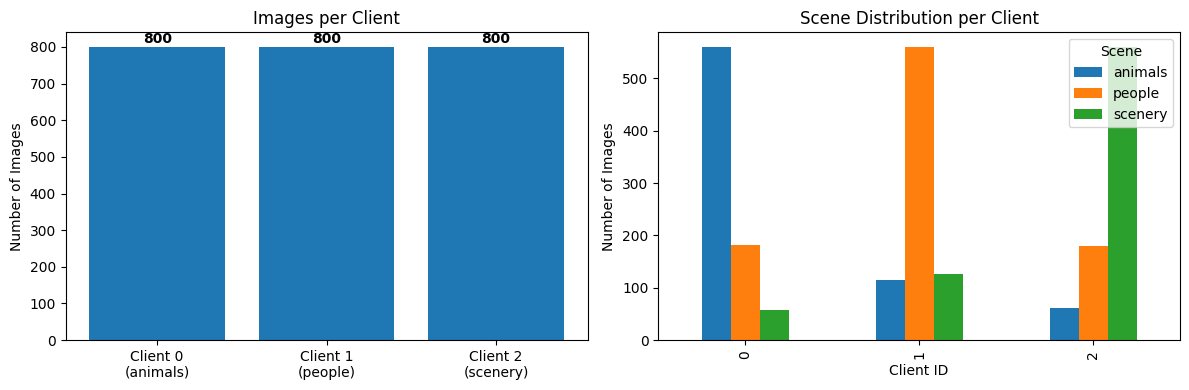

Saved plot: controlled_non_iid_distribution.png


In [ ]:
# ── Plot Controlled Non-IID Data Distribution ─────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# عدد الصور لكل client
client_counts = df_full["client_id"].value_counts().sort_index()

axes[0].bar(
    [f"Client {i}\n({SCENE_CLASSES[i]})" for i in client_counts.index],
    client_counts.values
)
axes[0].set_title("Images per Client")
axes[0].set_ylabel("Number of Images")

for i, v in enumerate(client_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# توزيع المشاهد داخل كل client
distribution = df_full.groupby(["client_id", "scene_label"]).size().unstack(fill_value=0)

distribution.plot(kind="bar", ax=axes[1])
axes[1].set_title("Scene Distribution per Client")
axes[1].set_xlabel("Client ID")
axes[1].set_ylabel("Number of Images")
axes[1].legend(SCENE_CLASSES, title="Scene")

plt.tight_layout()
plt.savefig("controlled_non_iid_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved plot: controlled_non_iid_distribution.png")

---
## Section 5 → Model Definition and Dataset Class

In [ ]:
# ── Model Definition ────────────────────────────────────────────────────
NUM_CLASSES = 3  # animals, people, scenery

def build_model() -> nn.Module:
    """
    MobileNetV2 مع فتح آخر 4 layers للتدريب — أفضل من تجميد الكل.
    """
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # جمّد أول 14 layer، وافتح آخر 4 layers
    for i, layer in enumerate(model.features):
        if i < 14:
            for param in layer.parameters():
                param.requires_grad = False
        else:
            for param in layer.parameters():
                param.requires_grad = True

    # Classifier للـ 3 classes
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return model


# Test the model
test_model  = build_model().to(DEVICE)
test_input  = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = test_model(test_input)

total_params     = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"Output shape: {test_output.shape}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
del test_model, test_input, test_output


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


Output shape: torch.Size([2, 3])
Total parameters: 2,227,715
Trainable parameters: 1,685,187


In [ ]:
# ── Dataset Class ─────────────────────────────────────────────────────
class SceneDataset(Dataset):


    # Transformations for training (with Data Augmentation)
    TRAIN_TRANSFORMS = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])
    ])

    # Transformations for evaluation (without augmentation)
    VAL_TRANSFORMS = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225])
    ])

    # For Client 2 (low-light): Adding additional dimming
    SCENERY_TRANSFORMS = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

    def __init__(self, df: pd.DataFrame, transform=None, client_id: int = -1):
        self.df        = df.reset_index(drop=True)
        self.client_id = client_id

        # Choosing the appropriate transformation
        if transform is not None:
            self.transform = transform
        elif client_id == 2:
            self.transform = self.SCENERY_TRANSFORMS
        else:
            self.transform = self.TRAIN_TRANSFORMS

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["scene_label"])

        if self.transform:
            image = self.transform(image)

        return image, label


# Dataset Test
sample_ds = SceneDataset(client_dfs[0], client_id=0)
img, lbl  = sample_ds[0]
print(f"✅{img.shape}")
print(f"✅ {lbl} ({SCENE_CLASSES[lbl]})")
print(f"✅The dataset size for Client 0:{len(sample_ds)} image")

✅torch.Size([3, 224, 224])
✅ 1 (people)
✅The dataset size for Client 0:800 image


Section 6 → Centralized Baseline Training

In [ ]:
# ── Building the Centralized Dataset ─────────────────────────────
df_centralized = pd.concat(list(client_dfs.values())).reset_index(drop=True)
df_centralized = df_centralized.sample(frac=1, random_state=SEED).reset_index(drop=True)

# 80% train / 20% test
split_idx = int(0.8 * len(df_centralized))
df_train_c = df_centralized.iloc[:split_idx]
df_test_c  = df_centralized.iloc[split_idx:]

train_dataset_c = SceneDataset(df_train_c)
test_dataset_c  = SceneDataset(df_test_c, transform=SceneDataset.VAL_TRANSFORMS)

train_loader_c = DataLoader(train_dataset_c, batch_size=16, shuffle=True, num_workers=2)
test_loader_c  = DataLoader(test_dataset_c, batch_size=16, shuffle=False, num_workers=2)

print(f"Centralized Training set: {len(train_dataset_c)} image")
print(f"Centralized Test set: {len(test_dataset_c)} image")

Centralized Training set: 1920 image
Centralized Test set: 480 image


In [ ]:
# ── Training and Evaluation Functions ─────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += len(labels)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * len(labels)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += len(labels)

    return total_loss / total, correct / total


print("Training and evaluation functions are ready.")

Training and evaluation functions are ready.


In [ ]:
# ── Training Centralized Model ─────────────────────────────
CENTRAL_EPOCHS = 5

central_model = build_model().to(DEVICE)
central_optimizer = optim.Adam(central_model.parameters(), lr=5e-4)
central_criterion = nn.CrossEntropyLoss()

central_history = {
    "train_acc": [],
    "test_acc": [],
    "train_loss": [],
    "test_loss": []
}

print("Starting centralized training...\n")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Train Acc':>10} {'Test Loss':>10} {'Test Acc':>9}")
print("-" * 55)

for epoch in range(1, CENTRAL_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        central_model, train_loader_c, central_optimizer, central_criterion
    )
    te_loss, te_acc = evaluate(
        central_model, test_loader_c, central_criterion
    )

    central_history["train_acc"].append(tr_acc)
    central_history["test_acc"].append(te_acc)
    central_history["train_loss"].append(tr_loss)
    central_history["test_loss"].append(te_loss)

    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_acc:>10.3f} {te_loss:>10.4f} {te_acc:>9.3f}")

CENTRAL_FINAL_ACC = central_history["test_acc"][-1]

print(f"\nCentralized Final Accuracy: {CENTRAL_FINAL_ACC:.3f} ({CENTRAL_FINAL_ACC*100:.1f}%)")
torch.save(central_model.state_dict(), "central_model.pth")
print("Saved: central_model.pth")

Starting centralized training...

 Epoch  Train Loss  Train Acc  Test Loss  Test Acc
-------------------------------------------------------
     1      0.7683      0.632     0.7006     0.642
     2      0.6571      0.682     0.7163     0.673
     3      0.6030      0.714     0.7206     0.648
     4      0.5963      0.730     0.6669     0.683
     5      0.5033      0.780     0.7578     0.677

Centralized Final Accuracy: 0.677 (67.7%)
Saved: central_model.pth


##Section 7 → Federated Learning Setup

In [ ]:
# ── Helper Functions for Federated Learning ─────────────────────
from flwr.common import NDArrays
from typing import Dict, Tuple

def get_model_weights(model: nn.Module) -> NDArrays:
    return [val.cpu().numpy() for _, val in model.state_dict().items()]


def set_model_weights(model: nn.Module, weights: NDArrays) -> nn.Module:
    params_dict = zip(model.state_dict().keys(), weights)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}
    model.load_state_dict(state_dict, strict=True)
    return model


def create_client_loaders(client_id: int):
    df = client_dfs[client_id]

    split = int(0.8 * len(df))
    df_train = df.iloc[:split]
    df_test = df.iloc[split:]

    train_ds = SceneDataset(df_train, client_id=client_id)
    test_ds = SceneDataset(df_test, transform=SceneDataset.VAL_TRANSFORMS)

    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

    return train_loader, test_loader


print("Federated helper functions are ready.")

Federated helper functions are ready.


In [ ]:
# ── Flower Client Class with FedProx ─────────────────────────────
import flwr as fl

class FAVSClient(fl.client.NumPyClient):
    def __init__(self, client_id: int):
        self.client_id = client_id
        self.model = build_model().to(DEVICE)
        self.criterion = nn.CrossEntropyLoss()
        self.train_loader, self.test_loader = create_client_loaders(client_id)

    def get_parameters(self, config):
        return get_model_weights(self.model)

    def set_parameters(self, parameters):
        set_model_weights(self.model, parameters)

    def fit(self, parameters, config):
        self.set_parameters(parameters)

        global_params = [p.clone().detach() for p in self.model.parameters()]

        mu = config.get("mu", 0.05)
        local_epochs = config.get("local_epochs", 2)

        optimizer = optim.Adam(self.model.parameters(), lr=5e-4)

        for _ in range(local_epochs):
            self.model.train()

            for images, labels in self.train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                optimizer.zero_grad()
                outputs = self.model(images)

                loss = self.criterion(outputs, labels)

                # FedProx proximal term
                prox_term = sum(
                    ((p - g) ** 2).sum()
                    for p, g in zip(self.model.parameters(), global_params)
                )

                loss += (mu / 2) * prox_term

                loss.backward()
                optimizer.step()

        return get_model_weights(self.model), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, accuracy = evaluate(self.model, self.test_loader, self.criterion)

        return float(loss), len(self.test_loader.dataset), {"accuracy": float(accuracy)}


print("FAVSClient with FedProx is ready.")

FAVSClient with FedProx is ready.


##Section 8 → Federated Learning Simulation

In [ ]:
# ── Running Federated Learning Simulation ─────────────────────────
from flwr.simulation import start_simulation
import flwr as fl
import torch.nn as nn

NUM_CLIENTS = 3
NUM_ROUNDS = 1
LOCAL_EPOCHS = 1
FRACTION_FIT = 1.0

federated_history = {
    "round": [],
    "accuracy": [],
    "loss": []
}

def client_fn(cid: str):
    return FAVSClient(client_id=int(cid))

def evaluate_fn(server_round, parameters, config):
    global_model = build_model().to(DEVICE)
    set_model_weights(global_model, parameters)

    criterion = nn.CrossEntropyLoss()
    loss, acc = evaluate(global_model, test_loader_c, criterion)

    federated_history["round"].append(server_round)
    federated_history["accuracy"].append(acc)
    federated_history["loss"].append(loss)

    print(f"[Round {server_round}] Loss: {loss:.4f} | Accuracy: {acc:.3f} ({acc*100:.1f}%)")

    return float(loss), {"accuracy": float(acc)}

class FedProxStrategy(fl.server.strategy.FedAvg):
    def __init__(self, mu=0.05, **kwargs):
        super().__init__(**kwargs)
        self.mu = mu

strategy = FedProxStrategy(
    mu=0.05,
    fraction_fit=FRACTION_FIT,
    fraction_evaluate=FRACTION_FIT,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=evaluate_fn,
    on_fit_config_fn=lambda r: {"local_epochs": LOCAL_EPOCHS, "mu": 0.05},
)

print("Starting Federated Learning Simulation...")
print(f"Clients: {NUM_CLIENTS}")
print(f"Rounds: {NUM_ROUNDS}")
print(f"Local epochs: {LOCAL_EPOCHS}")
print("Strategy: FedProx")

fl_results = start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={"num_gpus": 0, "num_cpus": 1},
)

FEDERATED_FINAL_ACC = federated_history["accuracy"][-1] if federated_history["accuracy"] else 0

print("\nFederated Learning Completed!")
print(f"Federated Final Accuracy: {FEDERATED_FINAL_ACC:.3f} ({FEDERATED_FINAL_ACC*100:.1f}%)")
print(f"Centralized Accuracy: {CENTRAL_FINAL_ACC:.3f} ({CENTRAL_FINAL_ACC*100:.1f}%)")
print(f"Accuracy Gap: {(CENTRAL_FINAL_ACC - FEDERATED_FINAL_ACC)*100:.2f}%")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=1, no round_timeout


Starting Federated Learning Simulation...
Clients: 3
Rounds: 1
Local epochs: 1
Strategy: FedProx


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-04-27 09:08:41,339	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.28.0.12': 1.0, 'memory': 9298619188.0, 'CPU': 2.0, 'object_store_memory': 3985122508.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_gpus': 0, 'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=20196) 2026-04-27 09:08:56.207747: E external/

[Round 0] Loss: 1.1305 | Accuracy: 0.383 (38.3%)


(ClientAppActor pid=20196) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=20196) 
(ClientAppActor pid=20196)             This is a deprecated feature. It will be removed
(ClientAppActor pid=20196)             entirely in future versions of Flower.
(ClientAppActor pid=20196)         
(ClientAppActor pid=20196) [2026-04-27 09:09:23,328 E 20196 20327] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(ClientAppActor pid=20196) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()`

[Round 1] Loss: 0.6723 | Accuracy: 0.652 (65.2%)


(ClientAppActor pid=20195) 
(ClientAppActor pid=20195)         
(ClientAppActor pid=20195) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=20195)             This is a deprecated feature. It will be removed
(ClientAppActor pid=20195)             entirely in future versions of Flower.
(ClientAppActor pid=20196) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=20196) 
(ClientAppActor pid=20196)             This is a deprecated feature. It will be removed
(ClientAppActor pid=20196)             entirely in future versions of Flower.
(ClientAppActor pid=2019


Federated Learning Completed!
Federated Final Accuracy: 0.652 (65.2%)
Centralized Accuracy: 0.677 (67.7%)
Accuracy Gap: 2.50%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##Section 9 → Results and Comparison

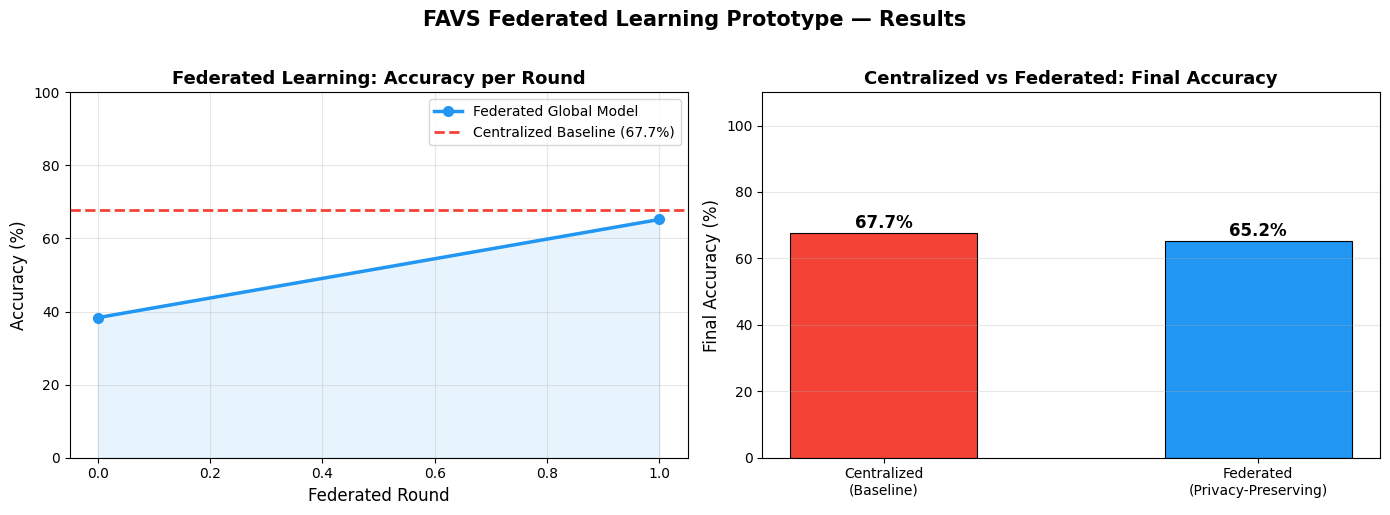

✅ The plot has been saved to: federated_results.png


In [ ]:
# ── Plotting Accuracy Curve Across the Rounds ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rounds = federated_history["round"]
fl_acc = [a * 100 for a in federated_history["accuracy"]]

# ─ Plot 1: Federated Accuracy per Round ─
axes[0].plot(rounds, fl_acc, "o-", color="#2196F3", linewidth=2.5,
             markersize=7, label="Federated Global Model", zorder=3)
axes[0].axhline(y=CENTRAL_FINAL_ACC * 100, color="#F44336", linestyle="--",
                linewidth=2, label=f"Centralized Baseline ({CENTRAL_FINAL_ACC*100:.1f}%)")
axes[0].fill_between(rounds, fl_acc, alpha=0.1, color="#2196F3")
axes[0].set_xlabel("Federated Round", fontsize=12)
axes[0].set_ylabel("Accuracy (%)", fontsize=12)
axes[0].set_title("Federated Learning: Accuracy per Round", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

# ─ Plot 2: Final Comparison Bar Chart ─
methods    = ["Centralized\n(Baseline)", "Federated\n(Privacy-Preserving)"]
accuracies = [CENTRAL_FINAL_ACC * 100, FEDERATED_FINAL_ACC * 100]
bar_colors = ["#F44336", "#2196F3"]

bars = axes[1].bar(methods, accuracies, color=bar_colors,
                   edgecolor="black", linewidth=0.8, width=0.5)
axes[1].set_ylabel("Final Accuracy (%)", fontsize=12)
axes[1].set_title("Centralized vs Federated: Final Accuracy",
                  fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 110)
axes[1].grid(True, axis="y", alpha=0.3)

for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                 f"{acc:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.suptitle("FAVS Federated Learning Prototype — Results",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("federated_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ The plot has been saved to: federated_results.png")

In [ ]:
# ── Full Results Summary ───────────────────────────────────────────────
print("=" * 60)
print("     FAVS Federated Learning Prototype — Results Summary")
print("=" * 60)
print(f"""
📊 Prototype Setup:
   • Number of Clients : {NUM_CLIENTS} (outdoor / indoor / low-light)
   • Number of Rounds  : {NUM_ROUNDS}
   • Local Epochs    : {LOCAL_EPOCHS} per round
   • Strategy        : FedAvg
   • Dataset         : Flickr8k (Non-IID split)

🎯 Accuracy Results:
   • Centralized Baseline : {CENTRAL_FINAL_ACC*100:.1f}%
   • Federated (Round 1)  : {federated_history['accuracy'][0]*100:.1f}%
   • Federated (Final)    : {FEDERATED_FINAL_ACC*100:.1f}%

🔒 Privacy Guarantees:
   • No images or raw data are sent to the server
   • Only model weights (Δw) are transmitted
   • Each user's data remains on their device

📈 Improvement of the Federated Model:
   • From {federated_history['accuracy'][0]*100:.1f}% → to {FEDERATED_FINAL_ACC*100:.1f}%
   • Over {NUM_ROUNDS} rounds of distributed learning
""")
print("=" * 60)

     FAVS Federated Learning Prototype — Results Summary


IndexError: list index out of range